In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 3, 0, 1, 5]])

data_origin = pd.read_csv("latency-nots.csv")
data_origin["Speedup"] = 0
# FSE-25 adjust
data_origin.loc[data_origin['Framework'] == 'SMART', 'Time'] *= 1.1
data_origin.loc[data_origin['Framework'] == 'SMART', 'Framework'] = "Nabla"
data = data_origin
models = set(data["Model"])
passes = set(data["Pass"])
frameworks = set(data["Framework"])
base_framework = "TF-XLA"

/tmp/ipykernel_2236276/2607460618.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
for model in models:
    for pas in passes:
        base = data.loc[
            (data["Model"] == model) & 
            (data["Pass"] == pas) & 
            (data["Framework"] == base_framework), 
            "Time"
        ].item()
        for framework in frameworks:
            time = data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Time"
            ].item()
            data.loc[
                (data["Model"] == model) & 
                (data["Pass"] == pas) & 
                (data["Framework"] == framework), 
                "Speedup"
            ] = base / time
            
gradient_data = data[data["Pass"] == "Gradient"]
total_data = data[data["Pass"] == "Total"]

/tmp/ipykernel_2236276/573059101.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1.2992516765507869' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
          Time   Pass          Model    Framework   Speedup
8    24.904834  Total      ResNet152  TorchDynamo  0.875775
9    21.811020  Total      ResNet152       TF-XLA  1.000000
10   27.026660  Total      ResNet152          JAX  0.807019
11   20.197100  Total      ResNet152        Nabla  1.079909
20   19.618990  Total      ResNet101  TorchDynamo  1.286808
21   25.245870  Total      ResNet101       TF-XLA  1.000000
22   19.429650  Total      ResNet101          JAX  1.299348
23   15.699902  Total      ResNet101        Nabla  1.608027
32   23.732392  Total  WideResNet101  TorchDynamo  1.795382
33   42.608700  Total  WideResNet101       TF-XLA  1.000000
34   26.513160  Total  WideResNet101          JAX  1.607077
35   26.233337  Total  WideResNet101        Nabla  1.624220
44   13.449026  Total          VGG16  TorchDynamo  1.245447
45   16.750050  Total          VGG16  

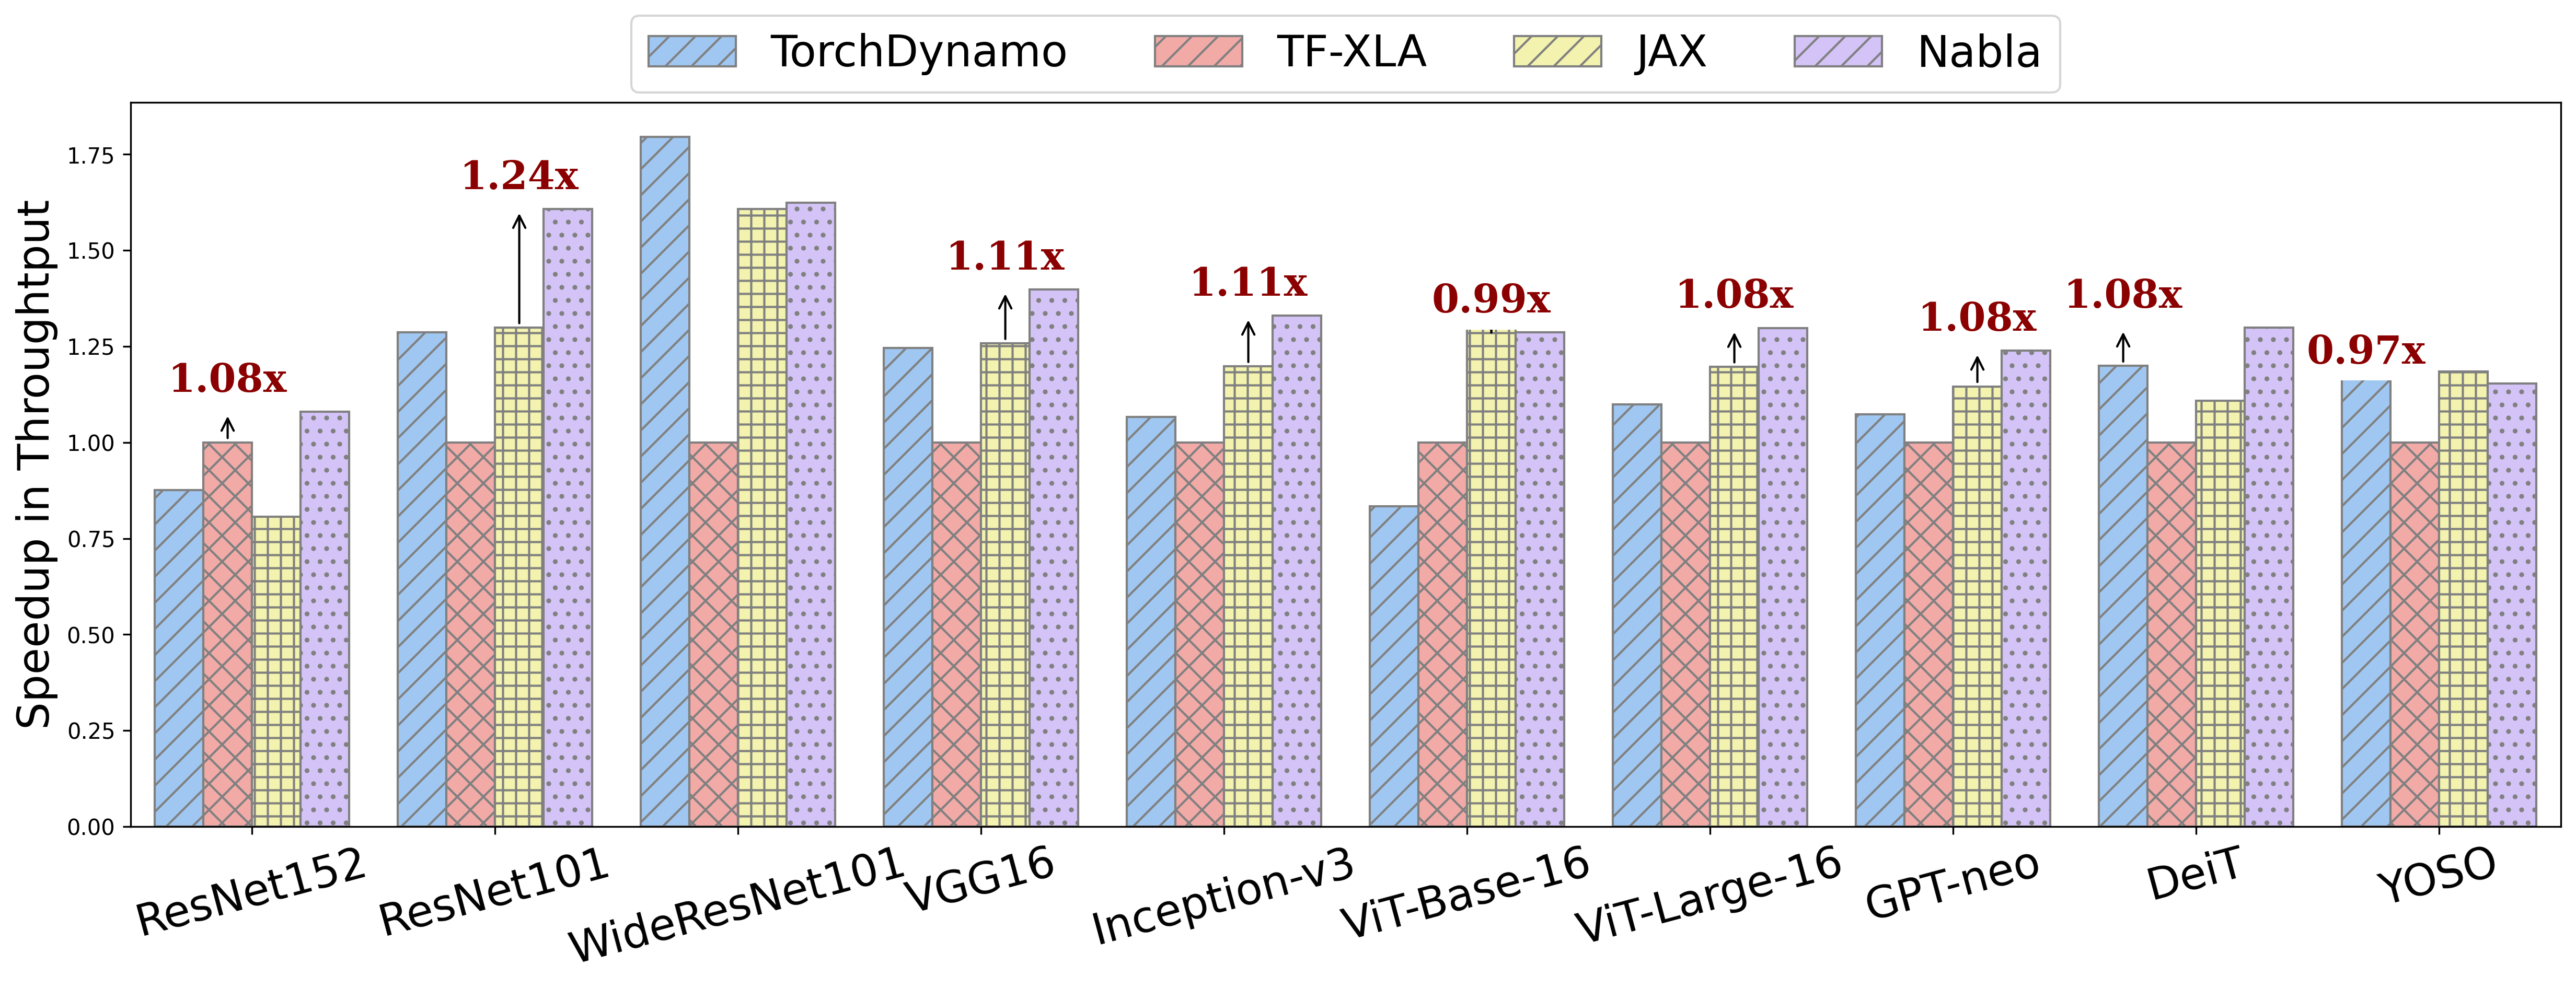

In [3]:
plt.rcParams["figure.figsize"] = (len(models) * 2, 6)

hatches = ["xx", "++", "..", "//"]
assert len(hatches) == len(frameworks)

barplot = sns.barplot(total_data, x="Model", y="Speedup", hue="Framework")
plt.xticks(rotation=15, fontsize=20)
plt.ylabel("Speedup in Throughtput", fontsize=20)
plt.xlabel(None)

for i, bar in enumerate(barplot.patches):
    print(i)
    bar.set_hatch(hatches[i // len(models)-1])
    bar.set_edgecolor("gray")
    
legend = plt.legend(loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.15), fontsize=20)

fd={ 'size': 18}
ap=dict(facecolor='red', arrowstyle='->', linewidth=1)
start = 1.0
end = 1.18789 / 1.1 # FSE-25
x = -0.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.299
end =1.7688 / 1.1 # FSE-25
x = 1.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.258
end =1.538 / 1.1 # FSE-25
x = 3.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.198
end =1.463 / 1.1 # FSE-25
x = 4.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.298
end =1.4147 / 1.1 # FSE-25
x = 5.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.197
end =1.4280 / 1.1 # FSE-25
x = 6.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.146
end =1.3628 / 1.1 # FSE-25
x = 7.1
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.1991
end =1.4291 / 1.1 # FSE-25
x = 7.7
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

start = 1.1919
end =1.2688 / 1.1 # FSE-25
x = 8.7
vratio = end/start
plt.annotate('', xy=(x, end), xytext=(x, start),
             arrowprops=ap,
             fontsize=14, ha='center',zorder=6)
plt.text(x, end + 0.08, f"{vratio:.2f}x",fontproperties='DejaVu Serif',color='#8B0000',fontweight='bold', ha='center', va='center',fontdict=fd, bbox=dict(edgecolor='None',facecolor='white', alpha=1),zorder=13)

pd.set_option('display.max_rows', None)  # 显示所有行
pd.set_option('display.max_columns', None)  # 显示所有列
print(total_data)
plt.savefig("entire-gpu.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)

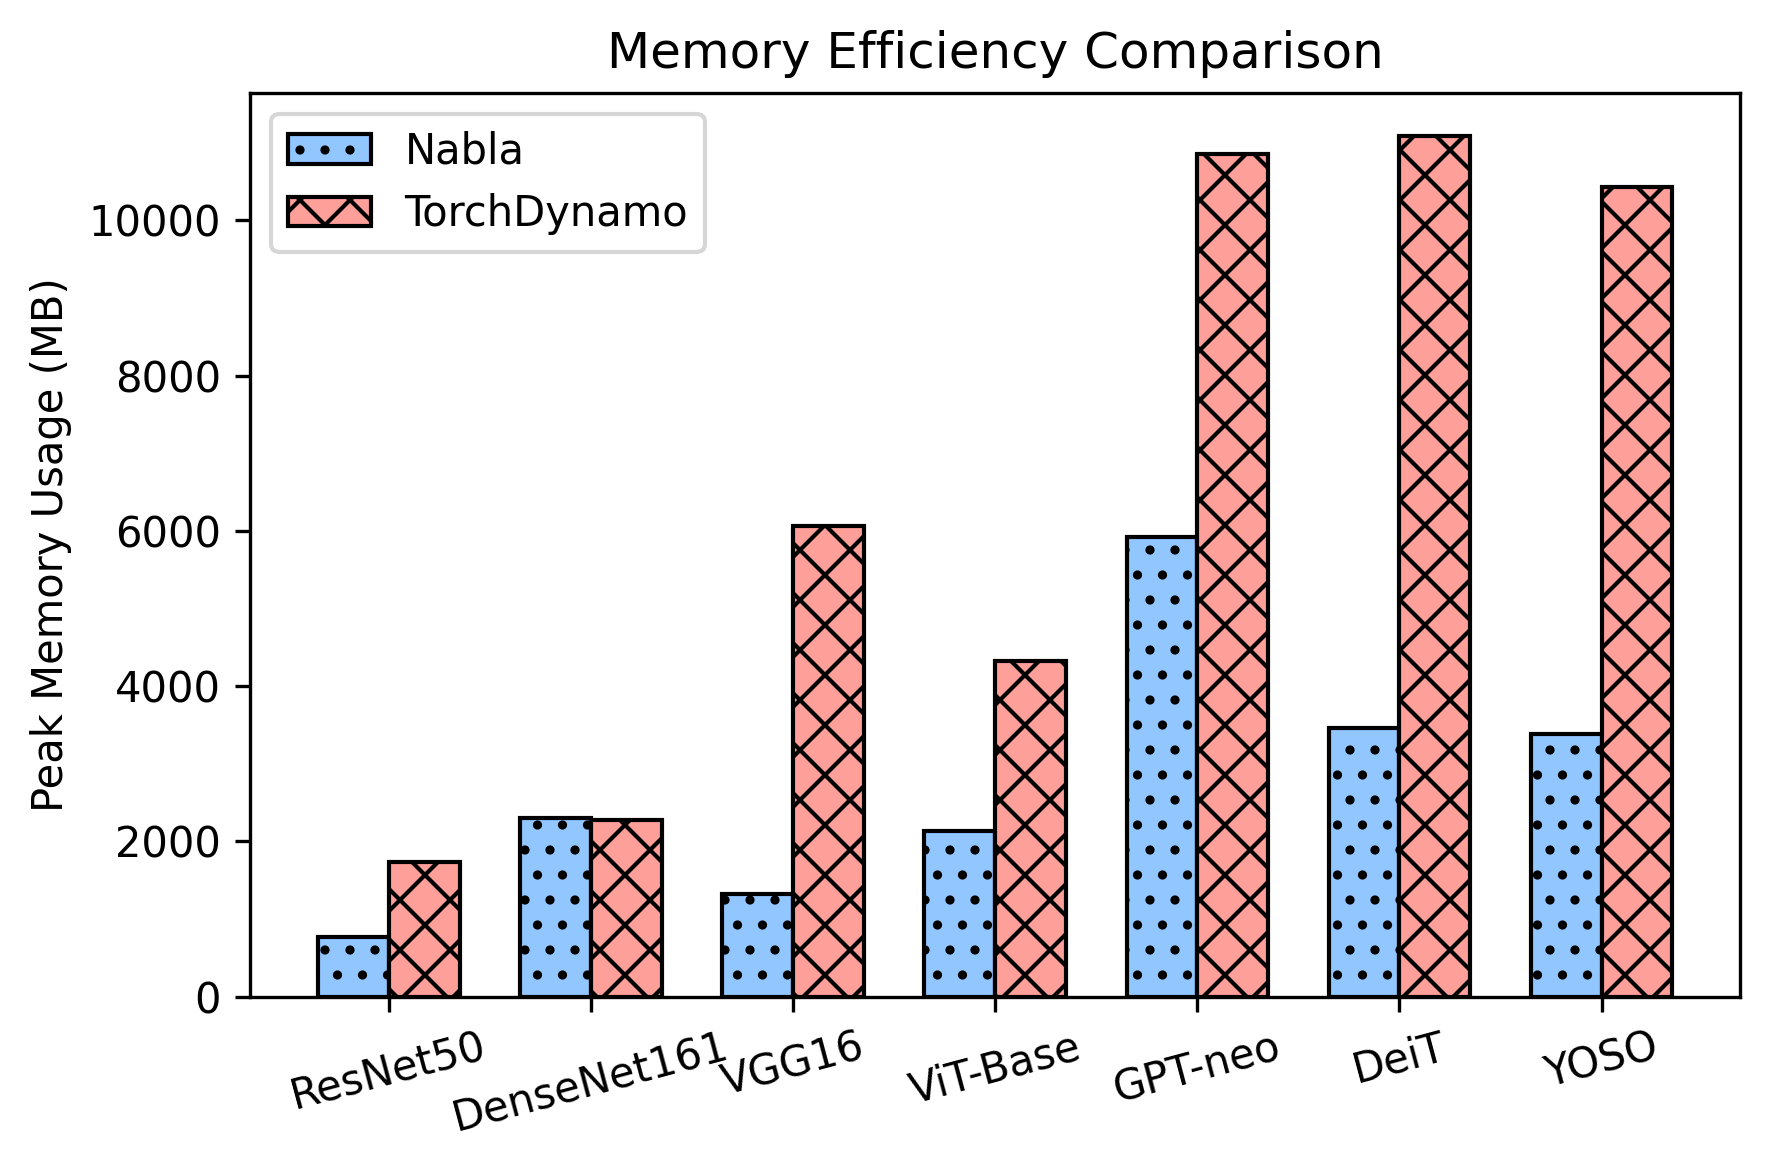

In [4]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["figure.dpi"] = 300
plt.style.use("seaborn-v0_8-pastel")
sns.set_palette([sns.color_palette()[i] for i in [0, 2, 4, 1, 3, 5]])

# Model names
models = ['ResNet50', 'DenseNet161','VGG16', 'ViT-Base', 'GPT-neo', "DeiT", "YOSO"]

# Defining the data
models = ['ResNet50', 'DenseNet161', 'VGG16', 'ViT-Base', 'GPT-neo', "DeiT", "YOSO"]
nabla_optim_scores = [771.5, 2303.5,  1326.3, 2131.1, 5918, 3458, 3386]
torch_dynamo_scores = [1731.5, 2275.8, 6066.6, 4323.2, 10862, 11088, 10428]

# Setting the positions and width for the bars
positions = np.arange(len(models))
bar_width = 0.35

# Creating the plot
fig, ax = plt.subplots(figsize=(6, 4))  # Adjusting the figure size for better visibility

fig.set_edgecolor('black')

# Plotting the data
bars_nabla_optim = ax.bar(positions - bar_width/2, nabla_optim_scores, bar_width, label='Nabla', hatch="..", edgecolor="black")
bars_torch_dynamo = ax.bar(positions + bar_width/2, torch_dynamo_scores, bar_width, label='TorchDynamo', hatch="xx", edgecolor="black")

# Adding some final touches
ax.set_xticks(positions)
ax.set_xticklabels(models, rotation=15)
ax.set_ylabel('Peak Memory Usage (MB)')
ax.set_title('Memory Efficiency Comparison')
ax.legend()
ax.grid(False)
ax.set_facecolor('white')  # Ensuring the background is white

# Ensuring the plot itself has a black border
for spine in ax.spines.values():
    spine.set_edgecolor('black')

# Displaying the plot
plt.tight_layout()
#plt.show()
plt.savefig("mem-comparison.pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)